Image Processing using Open CV

AGENDA
- Original project plan
- New Project Idea
- Prototyping
- Application

Original Project Plan

- Find high-resolution picture of the moon.
- Single out the craters on the face of the moon.
- Calculate distance of craters.
- Annotate image with findings

Problems

- Some high-resolution pictures of the moon had me struggling to see clearly defined craters
- Pictures online often lacked the scale
- Seems really hard 

Pivot

Classify US Coins and Annotating the Image

Prototype

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#blank white image (500x500 pixels)
img = np.full((500, 500, 3), 255, dtype=np.uint8)
coins = [
    {"center": (100, 100), "radius": 20, "color": (192, 192, 192)},
    {"center": (300, 100), "radius": 25, "color": (50, 100, 200)},
    {"center": (100, 300), "radius": 30, "color": (180, 180, 180)}, 
    {"center": (300, 300), "radius": 35, "color": (220, 220, 220)},
]

In [3]:
#draw coins
for coin in coins:
    center = coin["center"]
    radius = coin["radius"]
    color = coin["color"]
    
    #draw the coin
    cv2.circle(img, center, radius, color, -1)
    cv2.circle(img, center, radius, (0, 0, 0), 2) #outline

#save image
cv2.imwrite("synthetic_coins.jpg", img)

True

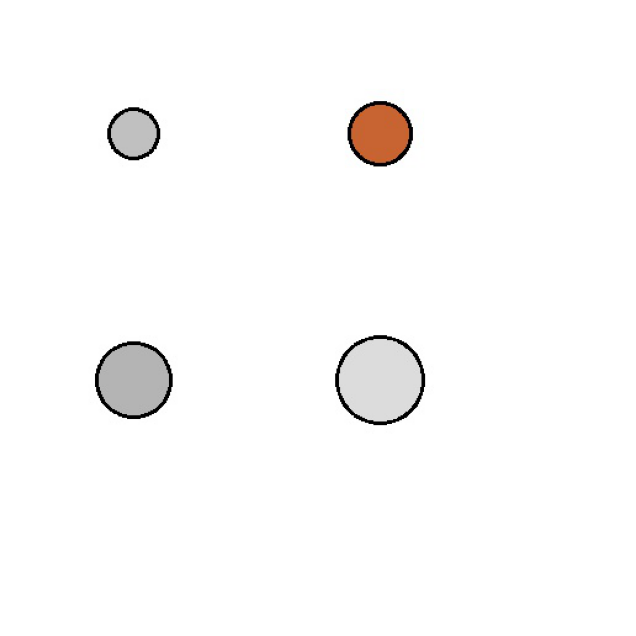

In [4]:
#load image
annotated_img = cv2.imread("synthetic_coins.jpg")
annotated_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8, 8))
plt.imshow(annotated_img)
plt.axis("off")
plt.show()

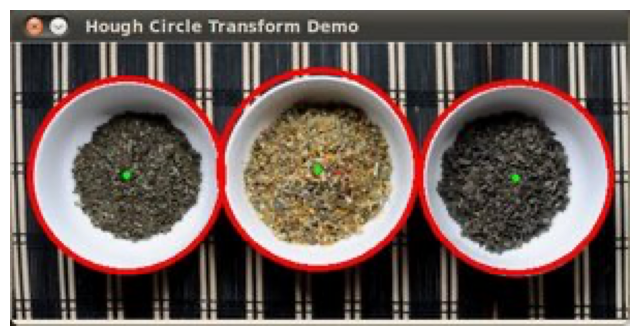

In [127]:
#load image
annotated_img = cv2.imread("image.png")
annotated_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8, 8))
plt.imshow(annotated_img)
plt.axis("off")
plt.show()

In [5]:
def identify_coin(radius, image, center):
    #create a mask for the coin region
    mask = np.zeros(image.shape[:2], dtype=np.uint8)
    cv2.circle(mask, center, int(radius), 255, -1)
    avg_b, avg_g, avg_r, _ = cv2.mean(image, mask=mask)

    if radius < 23:
        return "Dime"
    elif radius < 28:
        if avg_r > avg_b + 20:
            return "Penny"
        else:
            return "Dime"
    elif radius < 32:
        return "Nickel"
    else:
        return "Quarter"

In [7]:
#load image
img = cv2.imread("synthetic_coins.jpg")

#use a Gaussian blur to reduce noise and avoid false circle detection
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)

#use the Hough Circle Transform to detect the coins
circles = cv2.HoughCircles(
    blur, cv2.HOUGH_GRADIENT,
    dp=1.2, minDist=50, param1=50,
    param2=30, minRadius=20, maxRadius=100
)

In [9]:
circles = np.uint16(np.around(circles))
for i in circles[0, :]:
    center = (i[0], i[1])
    radius = i[2]
    coin_value = identify_coin(radius, img, center)
    
    #draw the detected coin circle (green) and its center (red)
    cv2.circle(img, center, radius, (0, 255, 0), 2)
    cv2.circle(img, center, 2, (0, 0, 255), 3)
    
    #Say what coin it is
    cv2.putText(img, coin_value, (center[0] - 40, center[1]),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
# Save the annotated image to a file.
cv2.imwrite("annotated_coins.jpg", img)

True

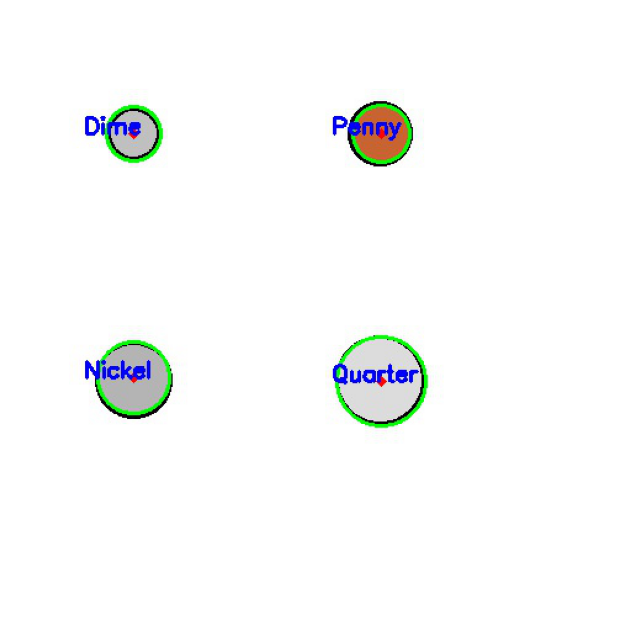

In [10]:
# load image
annotated_img = cv2.imread("annotated_coins.jpg")
annotated_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8, 8))
plt.imshow(annotated_img)
plt.axis("off")
plt.show()

Application

Use a real image of Coins

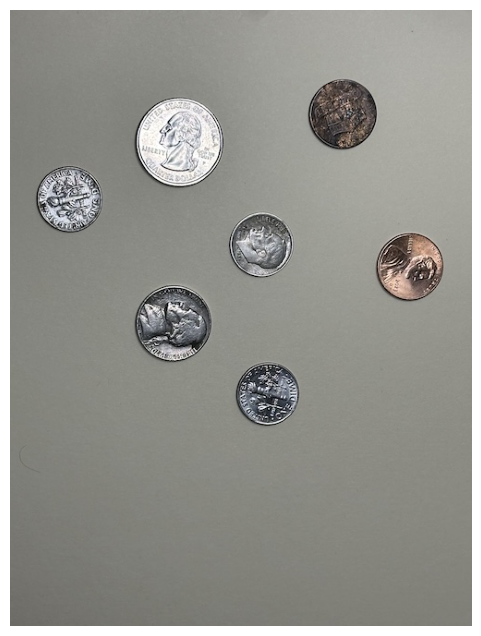

In [119]:
#load imgae
annotated_img = cv2.imread("coin_2.jpeg")
annotated_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8, 8))
plt.imshow(annotated_img)
plt.axis("off")
plt.show()

In [12]:
def identify_coin(radius, image, center):
    # create a mask for the coin region
    mask = np.zeros(image.shape[:2], dtype=np.uint8)
    cv2.circle(mask, center, int(radius), 255, -1)
    avg_b, avg_g, avg_r, _ = cv2.mean(image, mask=mask)

    if radius < 30:
        return "Dime"
    elif radius < 39:
        if avg_r > avg_b + 20:
            return "Penny"
        else:
            return "Dime"
    elif radius < 45:
        return "Nickel"
    else:
        return "Quarter"

In [13]:
#dictionary of values
value_map = {"Penny": 0.01, "Nickel": 0.05, "Dime": 0.10, "Quarter": 0.25,}
total_value = 0.0
coin_count = 0

In [133]:
#load image
img = cv2.imread("coin_1.jpeg")

#convert to grayscale and apply a Gaussian blur to reduce noise.
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (7, 7), 0)

In [134]:
#HoughCircles detect the coins
circles = cv2.HoughCircles(
    blur,
    cv2.HOUGH_GRADIENT,
    dp=1.0, minDist=40,
    param1=50, param2=30,
    minRadius=15,  # Minimum coin radius in pixels
    maxRadius=100  # Maximum coin radius in pixels
)

In [135]:
circles = np.uint16(np.around(circles))
for circle in circles[0, :]:
    center = (circle[0], circle[1])
    radius = circle[2]
    
    #identify each coin based on radius and color
    coin_type = identify_coin(radius, img, center)
    coin_value = value_map.get(coin_type, 0)
    total_value += coin_value
    coin_count += 1
    
    #draw coin
    cv2.circle(img, center, radius, (0, 255, 0), 2)
    cv2.circle(img, center, 2, (0, 0, 255), 3)
    
    #say what type of coin it is
    cv2.putText(img, coin_type, (center[0] - 40, center[1]),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)

In [136]:
#Save total value & # of coins
summary_text = f"Total: ${total_value:.2f} ({coin_count} coins)"
cv2.putText(img, summary_text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 2)

#save file
cv2.imwrite("annotated_coins.jpg", img)

True

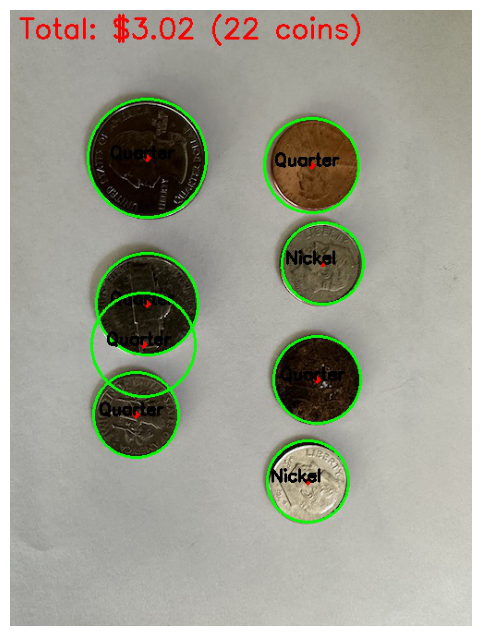

In [137]:
#load image
annotated_img = cv2.imread("annotated_coins.jpg")
annotated_img= cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8, 8))
plt.imshow(annotated_img)
plt.axis("off")
plt.show()